<a href="https://colab.research.google.com/github/PasinduDil/ML-exercise/blob/main/Classification_and_clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
#import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Load the dataset
df = pd.read_csv('/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

In [40]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [41]:
df.shape

(70692, 22)

In [42]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


##Data Cleaning

In [45]:
for i in df.columns:
    print(f"Null values in {i} are {df[i].isna().sum()}")


Null values in Diabetes_binary are 0
Null values in HighBP are 0
Null values in HighChol are 0
Null values in CholCheck are 0
Null values in BMI are 0
Null values in Smoker are 0
Null values in Stroke are 0
Null values in HeartDiseaseorAttack are 0
Null values in PhysActivity are 0
Null values in Fruits are 0
Null values in Veggies are 0
Null values in HvyAlcoholConsump are 0
Null values in AnyHealthcare are 0
Null values in NoDocbcCost are 0
Null values in GenHlth are 0
Null values in MentHlth are 0
Null values in PhysHlth are 0
Null values in DiffWalk are 0
Null values in Sex are 0
Null values in Age are 0
Null values in Education are 0
Null values in Income are 0


In [46]:
df.duplicated().sum()

1635

In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df.duplicated().sum()

0

In [49]:
df.shape

(69057, 22)

In [50]:
# Separate features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

In [51]:
# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [52]:
# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Classification Model (Random Forest)

In [53]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [54]:
# Evaluate the Classification Model
y_pred = clf.predict(X_val)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

In [55]:
# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Accuracy: 0.7320204652958779
Precision: 0.7268258426966292
Recall: 0.7723880597014925
F1-Score: 0.7489146164978292


#Clustering Model (K-Means)

In [56]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

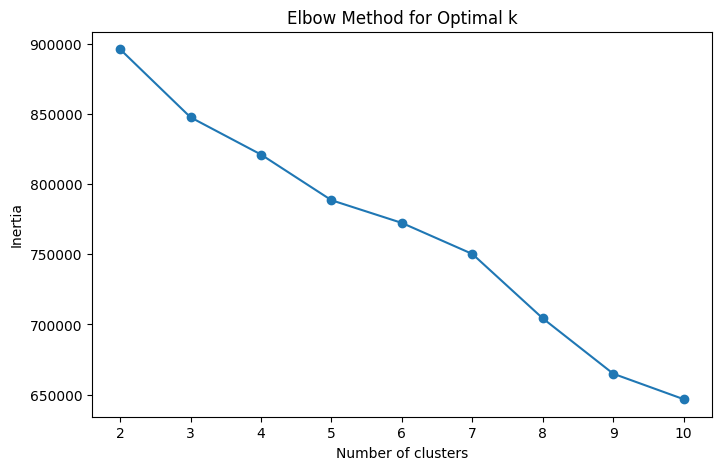

In [57]:
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [58]:
# Choose the optimal number of clusters
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

KMeans(n_clusters=2, random_state=42)

In [59]:
# Evaluate the Clustering Model
labels = kmeans.labels_
silhouette_avg = silhouette_score(X_train, labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.158573001328921


##Optimize the Model

In [60]:
from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [61]:
# Retrain the Random Forest Classifier with PCA
clf_pca = RandomForestClassifier(random_state=42)
clf_pca.fit(X_train_pca, y_train)

RandomForestClassifier(random_state=42)

In [62]:
# Evaluate the PCA-based Classification Model
y_pred_pca = clf_pca.predict(X_val_pca)

accuracy_pca = accuracy_score(y_val, y_pred_pca)
precision_pca = precision_score(y_val, y_pred_pca)
recall_pca = recall_score(y_val, y_pred_pca)
f1_pca = f1_score(y_val, y_pred_pca)

print(f"PCA Accuracy: {accuracy_pca}")
print(f"PCA Precision: {precision_pca}")
print(f"PCA Recall: {recall_pca}")
print(f"PCA F1-Score: {f1_pca}")

PCA Accuracy: 0.7298001737619462
PCA Precision: 0.728538283062645
PCA Recall: 0.7615671641791045
PCA F1-Score: 0.7446866733558333


##Data Visualization

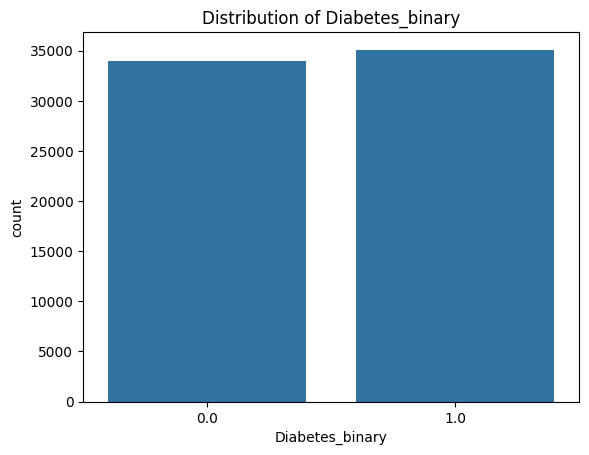

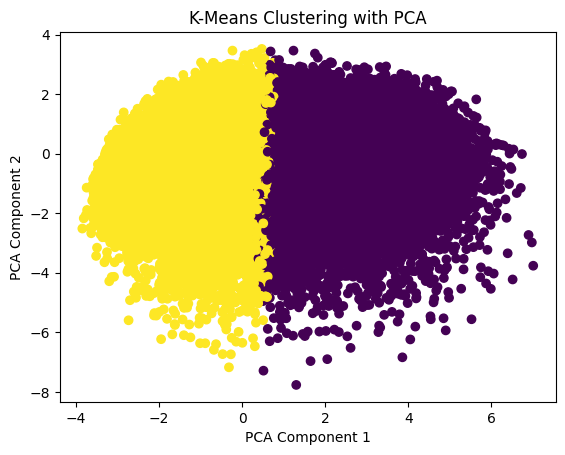

In [63]:
# Visualize the distribution of the target variable
sns.countplot(x='Diabetes_binary', data=df)
plt.title('Distribution of Diabetes_binary')
plt.show()

# Visualize the clusters
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('K-Means Clustering with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()